In [1]:
# importing required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [2]:
# loading the data
data=pd.read_excel('/content/drive/MyDrive/City Power Consumption.xlsx')
data.head()

,S no,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Air Quality Index (PM),Cloudiness,Power Consumption in A Zone
0,1,6.559,73.8,0.083,0.051,0.119,158.0,1,34055.69620
1,2,6.414,74.5,0.083,0.070,0.085,159.0,1,29814.68354
2,3,6.313,74.5,0.080,0.062,0.100,151.0,1,29128.10127
3,4,6.121,75,0.083,0.091,0.096,151.0,1,28228.86076
4,5,5.921,75.7,0.081,0.048,0.085,154.0,1,27335.69620


In [3]:
# checking rows and columns
data.shape

(52583, 9)

In [4]:
# checking data type
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52583 entries, 0 to 52582
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   S no                          52583 non-null  int64  
 1   Temperature                   52263 non-null  object 
 2   Humidity                      52558 non-null  object 
 3   Wind Speed                    52512 non-null  float64
 4   general diffuse flows         52275 non-null  float64
 5   diffuse flows                 52568 non-null  float64
 6   Air Quality Index (PM)        52565 non-null  float64
 7   Cloudiness                    52583 non-null  int64  
 8    Power Consumption in A Zone  52583 non-null  float64
dtypes: float64(5), int64(2), object(2)
memory usage: 3.6+ MB


In [5]:
# removing extra spaces from the feature name
data.columns=data.columns.str.strip()

In [6]:
# checking duplicate data
data.duplicated().sum()

np.int64(0)

In [7]:
# checking missing values
missing_data=pd.DataFrame({'Missing_count':data.isnull().sum(), 'Missing_Percentage':round(data.isnull().mean()*100,2)})
missing_data

,Missing_count,Missing_Percentage
S no,0,0.00
Temperature,320,0.61
Humidity,25,0.05
Wind Speed,71,0.14
general diffuse flows,308,0.59
diffuse flows,15,0.03
Air Quality Index (PM),18,0.03
Cloudiness,0,0.00
Power Consumption in A Zone,0,0.00


In [8]:
# converting the variable from object to numeric
data['Temperature']=pd.to_numeric(data['Temperature'])

ValueError: Unable to parse string "5.488 dc" at position 470

In [ ]:
# Show values that cannot be converted to numbers
temp=data[pd.to_numeric(data['Temperature'], errors='coerce').isna()]
temp['Temperature'].unique()

array([nan, '5.488 dc', '13.65 CD', '12.31 dc'], dtype=object)

In [ ]:
# replacing the values
data['Temperature']=(data['Temperature'].astype(str).str.extract(r'([-+]?\d*\.?\d+)', expand=False))

In [ ]:
# converting to numerical data
data['Temperature']=pd.to_numeric(data['Temperature'], errors='coerce')

In [9]:
data['Humidity']=pd.to_numeric(data['Humidity'])

ValueError: Unable to parse string "84.8 i" at position 719

In [ ]:
humid=data[pd.to_numeric(data['Humidity'], errors='coerce').isna()]
humid['Humidity'].unique()

array(['84.8 i', nan], dtype=object)

In [ ]:
data['Humidity']=(data['Humidity'].astype(str).str.extract(r'([-+]?\d*\.?\d+)', expand=False))

In [ ]:
data['Humidity']=pd.to_numeric(data['Humidity'], errors='coerce')

In [ ]:
# checking the data type after conversion
data.dtypes

,0
S no,int64
Temperature,float64
Humidity,float64
Wind Speed,float64
general diffuse flows,float64
diffuse flows,float64
Air Quality Index (PM),float64
Cloudiness,int64
Power Consumption in A Zone,float64


In [ ]:
# dropping S no as having no prediction power
data.drop('S no', axis=1, inplace=True)

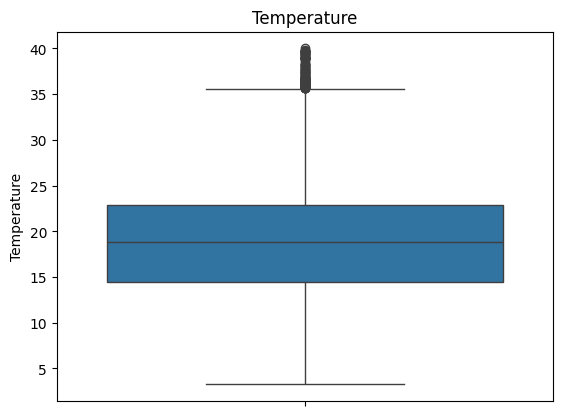

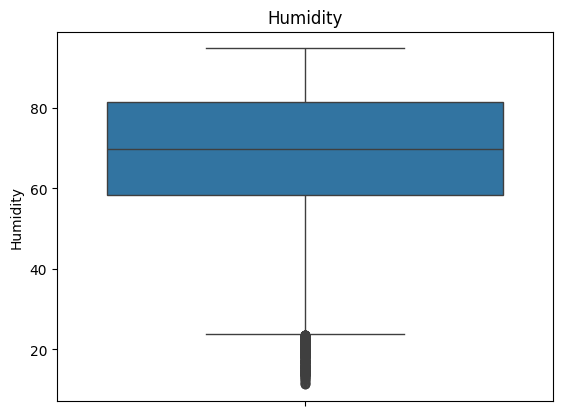

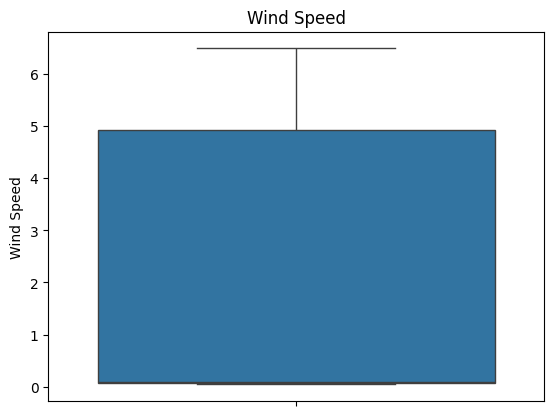

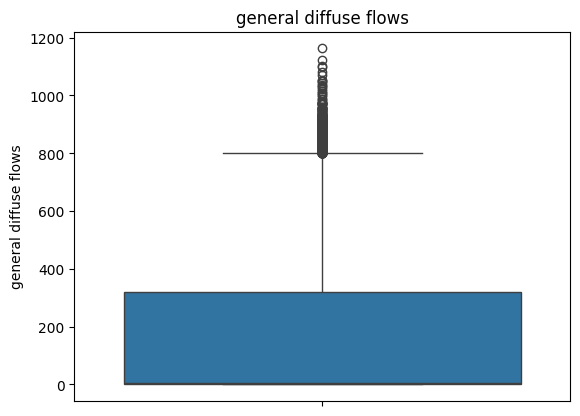

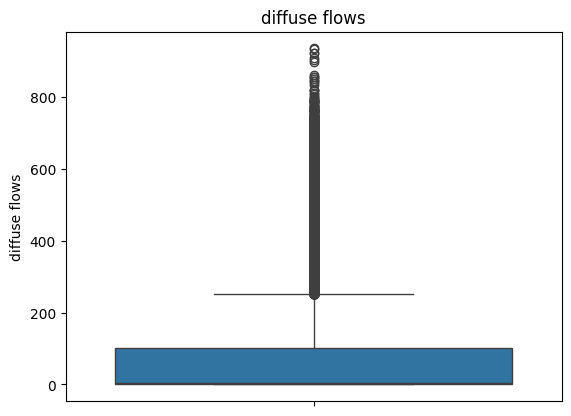

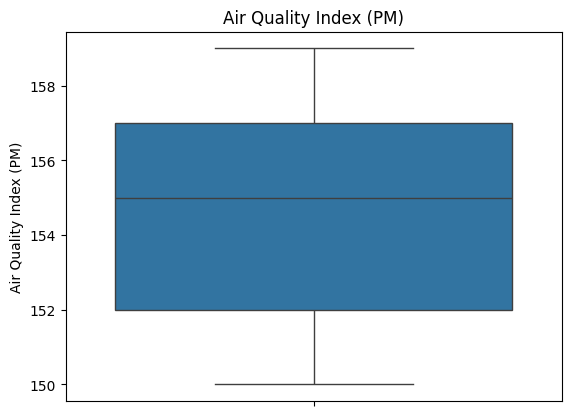

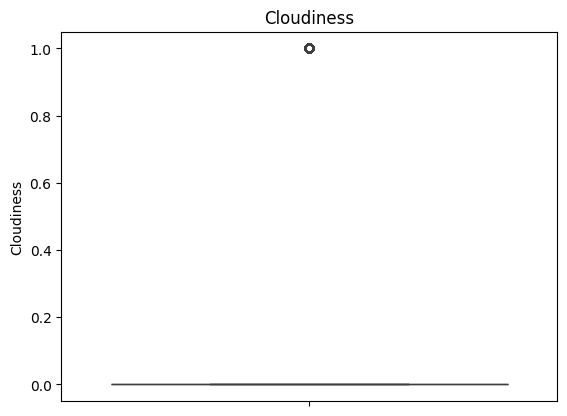

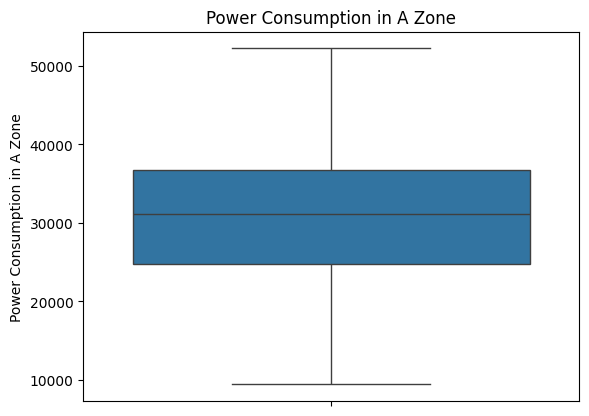

In [ ]:
# checking boxplot

for col in data.columns:
  sns.boxplot(data[col])
  plt.title(col)
  plt.show()

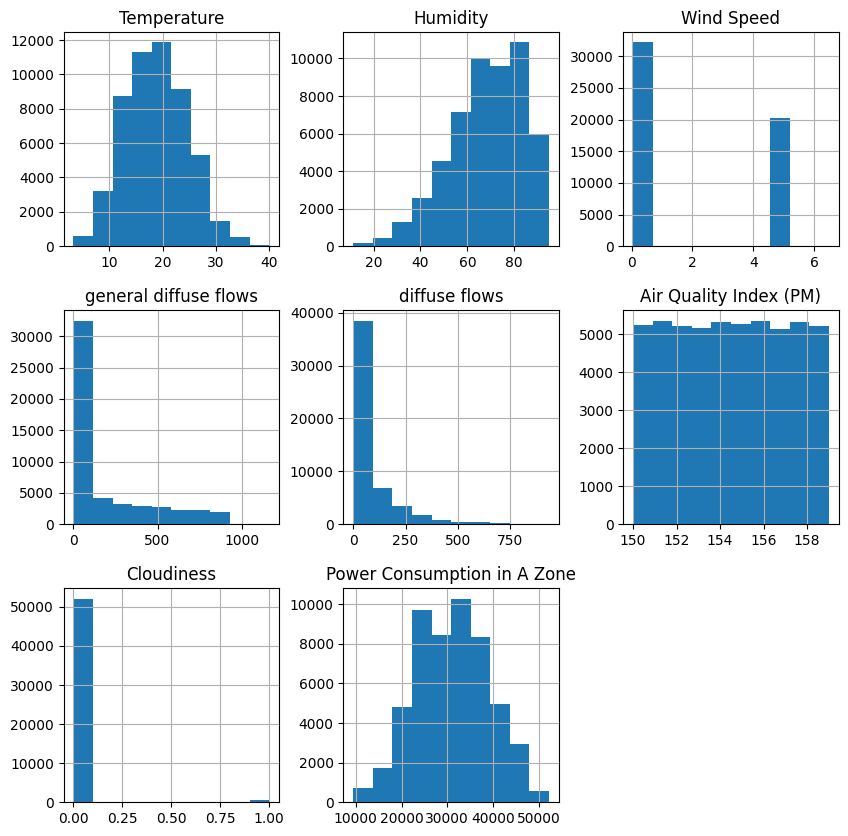

In [ ]:
# checking data distribution
data.hist(figsize=(10,10))
plt.show()

In [ ]:
# missing value treatment using median as most of the variables are not normally distributed
numeric_cols=data.select_dtypes(include='number').columns
data[numeric_cols]=data[numeric_cols].fillna(data[numeric_cols].median())

In [ ]:
data.isnull().sum()

,0
Temperature,0
Humidity,0
Wind Speed,0
general diffuse flows,0
diffuse flows,0
Air Quality Index (PM),0
Cloudiness,0
Power Consumption in A Zone,0


In [ ]:
# checking summary
data.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Temperature,52583.0,18.83,5.80,3.25,14.45,18.82,22.87,40.01
Humidity,52583.0,68.29,15.54,11.34,58.34,69.88,81.40,94.80
Wind Speed,52583.0,1.95,2.35,0.05,0.08,0.09,4.92,6.48
general diffuse flows,52583.0,181.92,264.14,0.00,0.06,5.23,317.00,1163.00
diffuse flows,52583.0,74.85,124.07,0.01,0.12,4.41,100.45,936.00
Air Quality Index (PM),52583.0,154.50,2.87,150.00,152.00,155.00,157.00,159.00
Cloudiness,52583.0,0.01,0.10,0.00,0.00,0.00,0.00,1.00
Power Consumption in A Zone,52583.0,31061.82,8021.06,9457.75,24738.86,31189.79,36721.58,52204.40


In [ ]:
# checking skewness
data.skew(numeric_only=True)

,0
Temperature,0.194395
Humidity,-0.627581
Wind Speed,0.468408
general diffuse flows,1.313883
diffuse flows,2.461325
Air Quality Index (PM),-0.001800
Cloudiness,10.203384
Power Consumption in A Zone,0.031528


In [ ]:
# checking correlation
data.corr().round(2)

,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Air Quality Index (PM),Cloudiness,Power Consumption in A Zone
Temperature,1.00,-0.46,0.48,0.46,0.20,-0.00,-0.09,0.56
Humidity,-0.46,1.00,-0.14,-0.47,-0.26,0.00,0.01,-0.23
Wind Speed,0.48,-0.14,1.00,0.14,0.00,0.00,-0.07,0.21
general diffuse flows,0.46,-0.47,0.14,1.00,0.56,-0.00,-0.02,0.21
diffuse flows,0.20,-0.26,0.00,0.56,1.00,-0.00,-0.03,0.06
Air Quality Index (PM),-0.00,0.00,0.00,-0.00,-0.00,1.00,-0.01,-0.00
Cloudiness,-0.09,0.01,-0.07,-0.02,-0.03,-0.01,1.00,-0.12
Power Consumption in A Zone,0.56,-0.23,0.21,0.21,0.06,-0.00,-0.12,1.00


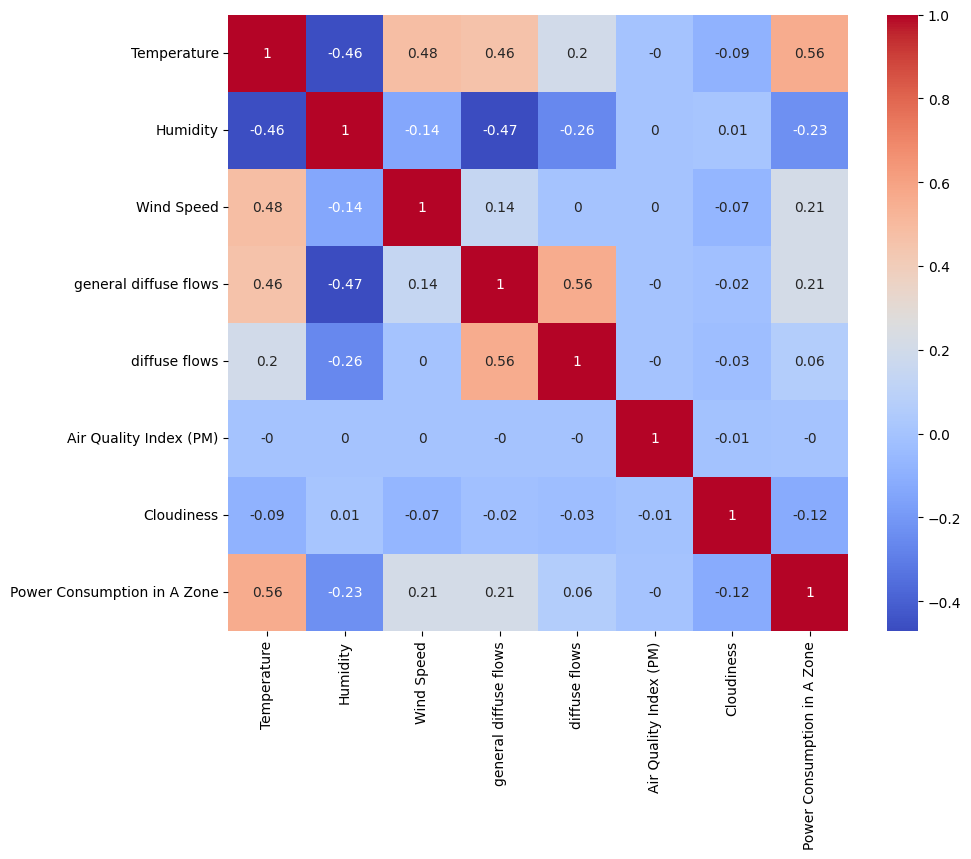

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr().round(2), annot=True, cmap='coolwarm')
plt.show()

In [ ]:
# checking for correlation of target variable with independent variables
corr=data.corr()['Power Consumption in A Zone']
corr.sort_values()

,Power Consumption in A Zone
Humidity,-0.230259
Cloudiness,-0.120694
Air Quality Index (PM),-0.001137
diffuse flows,0.062676
Wind Speed,0.207191
general diffuse flows,0.209634
Temperature,0.558778
Power Consumption in A Zone,1.000000


In [ ]:
# checking VIF for multicolinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor
data1=data.drop(columns=['Power Consumption in A Zone'])
vif=pd.DataFrame()
vif['Feature']=data1.columns
vif["VIF"]=[variance_inflation_factor(data1.values,i)
for i in range(data1.shape[1])]
vif=vif.sort_values(by='VIF', ascending=False)
vif


,Feature,VIF
5,Air Quality Index (PM),58.651456
1,Humidity,28.525923
0,Temperature,20.715881
3,general diffuse flows,2.872843
2,Wind Speed,2.232310
4,diffuse flows,2.027994
6,Cloudiness,1.020628


In [ ]:
# dropping Air Quality Index as showing highest VIF and negligible corelation with the target
data1=data1.drop(columns=['Air Quality Index (PM)'])
vif=pd.DataFrame()
vif['Feature']=data1.columns
vif["VIF"]=[variance_inflation_factor(data1.values,i)
for i in range(data1.shape[1])]
vif=vif.sort_values(by='VIF', ascending=False)
vif

,Feature,VIF
0,Temperature,11.027253
1,Humidity,6.587397
3,general diffuse flows,2.848655
2,Wind Speed,2.165549
4,diffuse flows,2.015666
5,Cloudiness,1.015609


In [ ]:
# splitting the data into independent and dependent variables
x=data.drop(columns=['Power Consumption in A Zone', 'Air Quality Index (PM)'])
y=data['Power Consumption in A Zone']

In [ ]:
# train test split
x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
# building OLS model (Stats approach)
from statsmodels.regression.linear_model import OLS
import statsmodels.regression.linear_model as smf

In [ ]:
regression=smf.OLS(endog=y_train, exog=x_train).fit()
regression.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     OLS Regression Results                                     
================================================================================================
Dep. Variable:     Power Consumption in A Zone   R-squared (uncentered):                   0.954
Model:                                     OLS   Adj. R-squared (uncentered):              0.954
Method:                          Least Squares   F-statistic:                          1.464e+05
Date:                         Sat, 11 Jul 2026   Prob (F-statistic):                        0.00
Time:                                 13:40:02   Log-Likelihood:                     -4.3126e+05
No. Observations:                        42066   AIC:                                  8.625e+05
Df Residuals:                            42060   BIC:                                  8.626e+05
Df Model:                                    6                                                  
Covariance Type:                     nonrobust                                                  
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Temperature            1180.6378      5.626    209.867      0.000    1169.611    1191.664
Humidity                141.5069      1.225    115.562      0.000     139.107     143.907
Wind Speed             -477.6645     16.105    -29.660      0.000    -509.230    -446.099
general diffuse flows    -0.2386      0.175     -1.363      0.173      -0.582       0.104
diffuse flows            -0.8454      0.327     -2.582      0.010      -1.487      -0.204
Cloudiness            -4743.4503    346.873    -13.675      0.000   -5423.328   -4063.573
==============================================================================
Omnibus:                      948.173   Durbin-Watson:                   2.019
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              979.324
Skew:                           0.358   Prob(JB):                    2.20e-213
Kurtosis:                       2.785   Cond. No.                     3.53e+03
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[3] The condition number is large, 3.53e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
# adding constant and re-building the OLS model
import statsmodels.api as sm

x_train_const = sm.add_constant(x_train)

ols_model = sm.OLS(endog=y_train, exog=x_train_const).fit()

print(ols_model.summary())

                                 OLS Regression Results                                
Dep. Variable:     Power Consumption in A Zone   R-squared:                       0.326
Model:                                     OLS   Adj. R-squared:                  0.325
Method:                          Least Squares   F-statistic:                     3384.
Date:                         Sat, 11 Jul 2026   Prob (F-statistic):               0.00
Time:                                 13:40:02   Log-Likelihood:            -4.2955e+05
No. Observations:                        42066   AIC:                         8.591e+05
Df Residuals:                            42059   BIC:                         8.592e+05
Df Model:                                    6                                         
Covariance Type:                     nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
------------------------------

In [ ]:
# scaling the data
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [ ]:
# building linear regression model
linear=LinearRegression()
linear.fit(x_train_scaled, y_train)

LinearRegression()

In [ ]:
y_pred_train_lr=linear.predict(x_train_scaled)
y_pred_test_lr=linear.predict(x_test_scaled)

In [ ]:
print("Training R2 score:", round(r2_score(y_train, y_pred_train_lr),4),'\n')
print("Test R2 score:", round(r2_score(y_test, y_pred_test_lr),4))


Training R2 score: 0.3256 

Test R2 score: 0.331


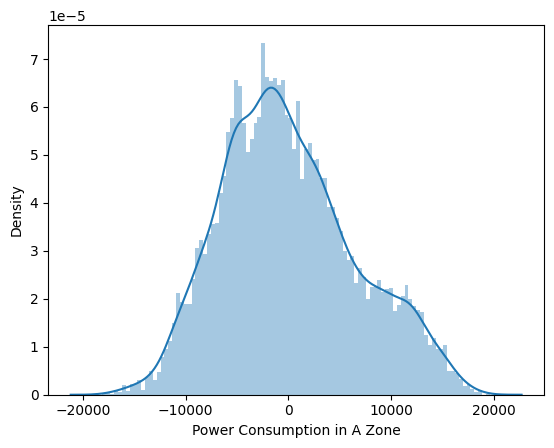

In [ ]:
# residual plot
sns.distplot((y_test-y_pred_test_lr), bins=100)
plt.show()

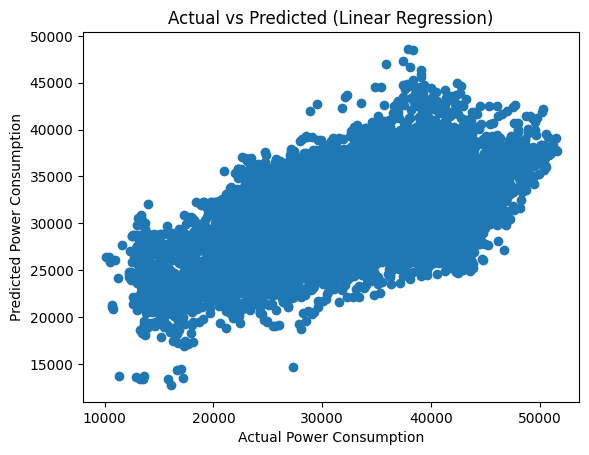

In [ ]:
# checking distribution of actual vs predicted value
plt.scatter(y_test, y_pred_test_lr)
plt.xlabel("Actual Power Consumption")
plt.ylabel("Predicted Power Consumption")
plt.title("Actual vs Predicted (Linear Regression)")
plt.show()

In [ ]:
# implementing regularization method
from sklearn.linear_model import Lasso
lasso=Lasso(alpha=0.2)
lasso.fit(x_train_scaled, y_train)

Lasso(alpha=0.2)

In [ ]:
y_pred_train_lasso=lasso.predict(x_train_scaled)
y_pred_test_lasso=lasso.predict(x_test_scaled)

In [ ]:
print("Training R2 score:", round(r2_score(y_train, y_pred_train_lasso),4),'\n')
print("Test R2 score:", round(r2_score(y_test, y_pred_test_lasso),4))

Training R2 score: 0.3256 

Test R2 score: 0.331


In [ ]:
from sklearn.linear_model import Ridge
ridge=Ridge(alpha=0.2)
ridge.fit(x_train_scaled, y_train)

Ridge(alpha=0.2)

In [ ]:
y_pred_train_ridge=ridge.predict(x_train_scaled)
y_pred_test_ridge=ridge.predict(x_test_scaled)

In [ ]:
print("Training R2 score:", round(r2_score(y_train, y_pred_train_ridge),4),'\n')
print("Test R2 score:", round(r2_score(y_test, y_pred_test_ridge),4))

Training R2 score: 0.3256 

Test R2 score: 0.331


In [ ]:
# no significant change observed after regularization

In [ ]:
data.head()

,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Air Quality Index (PM),Cloudiness,Power Consumption in A Zone
0,6.559,73.8,0.083,0.051,0.119,158.0,1,34055.69620
1,6.414,74.5,0.083,0.070,0.085,159.0,1,29814.68354
2,6.313,74.5,0.080,0.062,0.100,151.0,1,29128.10127
3,6.121,75.0,0.083,0.091,0.096,151.0,1,28228.86076
4,5.921,75.7,0.081,0.048,0.085,154.0,1,27335.69620


In [ ]:
# re-splitting the data for building tree based and ensemble models without dropping Air Quality Index
x=data.iloc[:,:-1]
y=data['Power Consumption in A Zone']

In [ ]:
x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.20, random_state=42)

In [ ]:
# building decision tree
dt=DecisionTreeRegressor(random_state=42)
dt.fit(x_train, y_train)

DecisionTreeRegressor(random_state=42)

In [ ]:
y_pred_train_dt=dt.predict(x_train)
y_pred_test_dt=dt.predict(x_test)

In [ ]:
print("Training R2 score:", round(r2_score(y_train, y_pred_train_dt),4),'\n')
print("Test R2 score:", round(r2_score(y_test, y_pred_test_dt),4))

Training R2 score: 0.9999 

Test R2 score: 0.2806


In [ ]:
# building random forest
rf = RandomForestRegressor(random_state=42)

rf.fit(x_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred_train_rf=dt.predict(x_train)
y_pred_test_rf=rf.predict(x_test)

In [ ]:
print("Training R2 score:", round(r2_score(y_train, y_pred_train_rf),4),'\n')
print("Test R2 score:", round(r2_score(y_test, y_pred_test_rf),4))

Training R2 score: 0.9999 

Test R2 score: 0.6379


In [ ]:
# building gradient boosting
gbr = GradientBoostingRegressor(random_state=42)

gbr.fit(x_train, y_train)

GradientBoostingRegressor(random_state=42)

In [ ]:
y_pred_train_gbr=gbr.predict(x_train)
y_pred_test_gbr=gbr.predict(x_test)

In [ ]:
print("Training R2 score:", round(r2_score(y_train, y_pred_train_gbr),4),'\n')
print("Test R2 score:", round(r2_score(y_test, y_pred_test_gbr),4))

Training R2 score: 0.4426 

Test R2 score: 0.4369


In [ ]:
# building XG boost
xgb = XGBRegressor(random_state=42)

xgb.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred_train_xgb=xgb.predict(x_train)
y_pred_test_xgb=xgb.predict(x_test)

In [ ]:
print("Training R2 score:", round(r2_score(y_train, y_pred_train_xgb),4),'\n')
print("Test R2 score:", round(r2_score(y_test, y_pred_test_xgb),4))

Training R2 score: 0.6654 

Test R2 score: 0.5563


In [ ]:
# comparing the models
results = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],

    "MAE":[
        mean_absolute_error(y_test,y_pred_test_lr),
        mean_absolute_error(y_test,y_pred_test_dt),
        mean_absolute_error(y_test,y_pred_test_rf),
        mean_absolute_error(y_test,y_pred_test_gbr),
        mean_absolute_error(y_test,y_pred_test_xgb)
    ],

    "RMSE":[
        np.sqrt(mean_squared_error(y_test,y_pred_test_lr)),
        np.sqrt(mean_squared_error(y_test,y_pred_test_dt)),
        np.sqrt(mean_squared_error(y_test,y_pred_test_rf)),
        np.sqrt(mean_squared_error(y_test,y_pred_test_gbr)),
        np.sqrt(mean_squared_error(y_test,y_pred_test_xgb))
    ],

    "R2":[
        r2_score(y_test,y_pred_test_lr),
        r2_score(y_test,y_pred_test_dt),
        r2_score(y_test,y_pred_test_rf),
        r2_score(y_test,y_pred_test_gbr),
        r2_score(y_test,y_pred_test_xgb)
    ]

})

results

,Model,MAE,RMSE,R2
0,Linear Regression,5295.942212,6573.815710,0.331033
1,Decision Tree,4141.332686,6816.896187,0.280646
2,Random Forest,3384.436064,4836.582974,0.637885
3,Gradient Boosting,4735.015290,6031.169430,0.436917
4,XGBoost,3957.382948,5353.992835,0.556264


In [ ]:
# found random forest as the best performing model. now doing hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 3, 5, 10],
    'max_features': ['sqrt', 'log2']
    }

rf = RandomForestRegressor(random_state=42)

grid = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    cv=5,
    scoring='r2',
    random_state=42
)

grid.fit(x_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}
Best CV Score: 0.5694797206323899


In [ ]:
best_model = grid.best_estimator_

y_pred_train_rf = best_model.predict(x_train)
y_pred_test_rf=best_model.predict(x_test)

In [ ]:
print(round(r2_score(y_train, y_pred_train_rf),2))
print(round(r2_score(y_test, y_pred_test_rf),2))

0.84
0.59


In [ ]:
# checking cross validation
scores = cross_val_score(best_model, x_train, y_train, cv=5, scoring='r2')

print(np.round(scores, 2))
print(round(scores.mean(),2))

[0.57 0.58 0.56 0.57 0.57]
0.57


In [ ]:
# re-comparing the models
results = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],

    "MAE":[
        mean_absolute_error(y_test,y_pred_test_lr),
        mean_absolute_error(y_test,y_pred_test_dt),
        mean_absolute_error(y_test,y_pred_test_rf),
        mean_absolute_error(y_test,y_pred_test_gbr),
        mean_absolute_error(y_test,y_pred_test_xgb)
    ],

    "RMSE":[
        np.sqrt(mean_squared_error(y_test,y_pred_test_lr)),
        np.sqrt(mean_squared_error(y_test,y_pred_test_dt)),
        np.sqrt(mean_squared_error(y_test,y_pred_test_rf)),
        np.sqrt(mean_squared_error(y_test,y_pred_test_gbr)),
        np.sqrt(mean_squared_error(y_test,y_pred_test_xgb))
    ],

    "R2":[
        r2_score(y_test,y_pred_test_lr),
        r2_score(y_test,y_pred_test_dt),
        r2_score(y_test,y_pred_test_rf),
        r2_score(y_test,y_pred_test_gbr),
        r2_score(y_test,y_pred_test_xgb)
    ]

})

results

,Model,MAE,RMSE,R2
0,Linear Regression,5295.942212,6573.815710,0.331033
1,Decision Tree,4141.332686,6816.896187,0.280646
2,Random Forest,3821.526833,5176.102217,0.585261
3,Gradient Boosting,4735.015290,6031.169430,0.436917
4,XGBoost,3957.382948,5353.992835,0.556264


In [ ]:
# checking for feature importance
importance = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': best_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                  Feature  Importance
0             Temperature    0.433885
1                Humidity    0.149681
2              Wind Speed    0.137171
3   general diffuse flows    0.121439
4           diffuse flows    0.111251
5  Air Quality Index (PM)    0.036804
6              Cloudiness    0.009770
